[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sterolose/sirius-statistics-2026/blob/main/notebooks/9_regression.ipynb)

## Семинар 9. Регрессионный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan

Приготовим пингвинов как раньше.

In [2]:
df = sns.load_dataset("penguins")
df.insert(2, "body_mass_kg", df.pop("body_mass_g") / 1000)
df = df.dropna()
adelie = df.loc[df["species"] == "Adelie"]
adelie.head(2)

,species,island,body_mass_kg,bill_length_mm,bill_depth_mm,flipper_length_mm,sex
0,Adelie,Torgersen,3.75,39.1,18.7,181.0,Male
1,Adelie,Torgersen,3.80,39.5,17.4,186.0,Female


Во всех заданиях используем уровень значимости $\alpha = 0.05$, для коэффициентов — двусторонние альтернативы.

### Задание 1

Построим простую линейную регрессию длины ласты от массы тела для Adelie. Сначала посмотрим на связь с помощью `sns.regplot`.

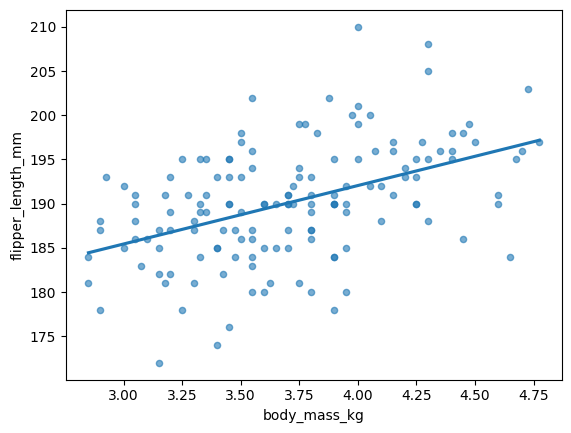

In [3]:
sns.regplot(
    adelie, x="body_mass_kg", y="flipper_length_mm",
    scatter_kws={"s": 20, "alpha": 0.6}, ci=None,
)
plt.show()

Используем знакомую функцию [`ols`](https://www.statsmodels.org/stable/example_formulas.html). Свободный член добавляется в модель автоматически.

In [4]:
model = ols("flipper_length_mm ~ body_mass_kg", adelie).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      flipper_length_mm   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     39.69
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           3.40e-09
Time:                        11:30:48   Log-Likelihood:                -462.66
No. Observations:                 146   AIC:                             929.3
Df Residuals:                     144   BIC:                             935.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      165.6032      3.918     42.267      0.000     157.859     173.348
body_mass_kg     6.6105      1.049      6.300      0.000       4.537       8.684
==============================================================================
Omnibus:                        0.992   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.609   Jarque-Bera (JB):                0.595
Skew:                          -0.023   Prob(JB):                        0.743
Kurtosis:                       3.309   Cond. No.                         32.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

В `summary` много информации. Выведем отдельно оценки коэффициентов, стандартные ошибки, p-value для $H_0: \beta_j = 0$ и 95%-е доверительные интервалы.

In [5]:
pd.DataFrame({
    "coef": model.params,
    "SE": model.bse,
    "p-value": model.pvalues,
}).join(model.conf_int().rename(columns={0: "CI low", 1: "CI high"}))

,coef,SE,p-value,CI low,CI high
Intercept,165.603241,3.918053,4.708343e-83,157.858915,173.347567
body_mass_kg,6.610473,1.049224,3.401644e-09,4.536603,8.684342


In [6]:
pd.Series({
    "R2": model.rsquared,
    "R2 adj": model.rsquared_adj,
    "RMSE": np.sqrt(np.mean(model.resid ** 2)),
    "F p-value": model.f_pvalue,
}).to_frame("value")

,value
R2,2.160892e-01
R2 adj,2.106454e-01
RMSE,5.754532e+00
F p-value,3.401644e-09


Главное — величина и смысл коэффициентов, их интервалы и диагностика остатков. $R^2$ показывает долю объясненной вариации, скорректированный $R^2$ учитывает число параметров, а RMSE здесь описывает ошибки на той же выборке. Общий F-тест проверяет, равны ли нулю все коэффициенты, кроме свободного члена.

Нормальность предполагается для ошибок модели, а не для исходных признаков. Проверим ее по остаткам. Гомоскедастичность означает постоянство дисперсии ошибок.

Используем тест Шапиро — Уилка и тест Бройша — Пагана (по умолчанию — вариант Кёнкера). Для второго берем последнее из четырех возвращаемых значений: p-value F-теста. В `model.model.exog` находится матрица признаков модели, включая свободный член.

In [7]:
pd.Series({
    "Shapiro-Wilk": stats.shapiro(model.resid).pvalue,
    "Breusch-Pagan": het_breuschpagan(model.resid, model.model.exog)[3],
}, name="p-value").to_frame()

,p-value
Shapiro-Wilk,0.562038
Breusch-Pagan,0.627050


Постройте гистограмму и Q–Q plot остатков.

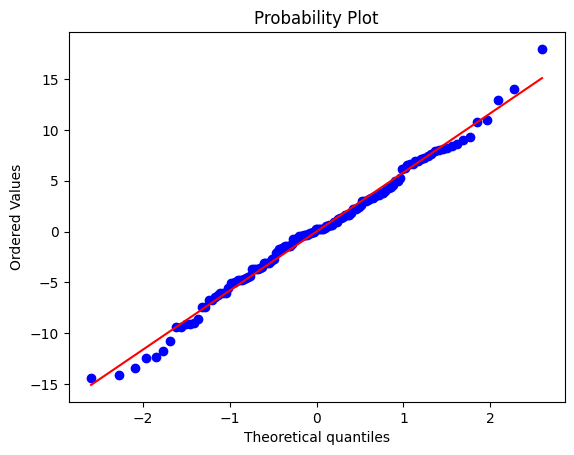

In [10]:
#plt.hist(model.resid, bins = 20)
stats.probplot(model.resid, plot = plt)
plt.show()

Посмотрим на предсказанные значения $\hat y$ в зависимости от наблюдаемого $y$ и остатки $e = y - \hat y$ в зависимости от $\hat y$. Их можно получить как `model.fittedvalues` и `model.resid`.

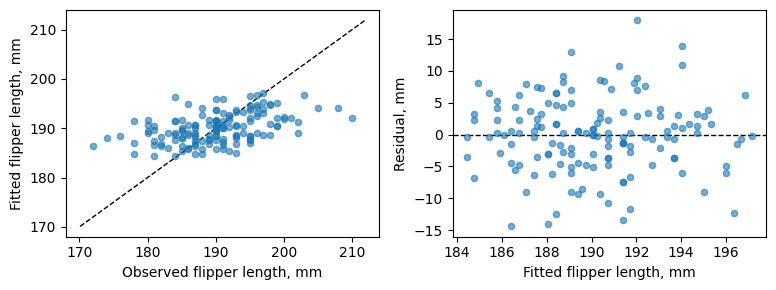

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].scatter(adelie["flipper_length_mm"], model.fittedvalues, s=20, alpha=0.6)
axes[0].plot(axes[0].get_xlim(), axes[0].get_xlim(), "k--", linewidth=1, zorder=0)
axes[0].set(xlabel="Observed flipper length, mm", ylabel="Fitted flipper length, mm")

axes[1].scatter(model.fittedvalues, model.resid, s=20, alpha=0.6)
axes[1].axhline(0, color="k", linestyle="--", linewidth=1, zorder=0)
axes[1].set(xlabel="Fitted flipper length, mm", ylabel="Residual, mm")

plt.tight_layout()
plt.show()

### Задание 2

Теперь для тех же Adelie будем моделировать **массу тела** по длине ласты, размерам клюва и полу. `C(sex)` обозначает категориальный признак; строковые столбцы распознаются как категориальные и без `C`.

Запись `flipper_length_mm * C(sex)` включает оба основных эффекта и их взаимодействие. Она позволяет наклону зависимости массы от длины ласты различаться между полами.

In [11]:
model = ols(
    "body_mass_kg ~ flipper_length_mm * C(sex) + bill_length_mm + bill_depth_mm",
    adelie,
).fit()

pd.DataFrame({
    "coef": model.params,
    "p-value": model.pvalues,
})

,coef,p-value
Intercept,-0.864295,0.499820
C(sex)[T.Male],-0.048064,0.974834
flipper_length_mm,0.012202,0.045472
flipper_length_mm:C(sex)[T.Male],0.002626,0.744674
bill_length_mm,0.020161,0.079133
bill_depth_mm,0.067556,0.006802


Упростим модель, начав с взаимодействия. Пока оно присутствует, сохраняем оба входящих в него основных эффекта.

В `statsmodels` сравнивать вложенные модели через `compare_f_test`.

In [12]:
reduced = ols(
    "body_mass_kg ~ flipper_length_mm + C(sex) + bill_length_mm + bill_depth_mm",
    adelie,
).fit()

pd.Series(
    model.compare_f_test(reduced),
    index=["F", "p-value", "df difference"],
).to_frame("value")

,value
F,0.106481
p-value,0.744674
df difference,1.000000


Отказ от взаимодействия не дает статистически значимого ухудшения. Продолжим с сокращенной моделью.

In [13]:
model = reduced
pd.DataFrame({"coef": model.params, "p-value": model.pvalues})

,coef,p-value
Intercept,-1.173612,1.714275e-01
C(sex)[T.Male],0.447731,8.333709e-10
flipper_length_mm,0.013685,7.606350e-04
bill_length_mm,0.020798,6.529386e-02
bill_depth_mm,0.067963,6.249422e-03


Уберите следующий незначимый признак и повторите сравнение вложенных моделей. Для итоговой модели выведите коэффициенты с интервалами, скорректированный $R^2$ и проверьте остатки. Постройте диаграммы рассеяния $\hat y$ от $y$ и $e$ от $\hat y$.

In [14]:
reduced = ols(
    "body_mass_kg ~ flipper_length_mm + C(sex) + bill_depth_mm",
    adelie,
).fit()

pd.Series(
    model.compare_f_test(reduced),
    index=["F", "p-value", "df difference"],
).to_frame("value")

,value
F,3.451140
p-value,0.065294
df difference,1.000000


### Задание 3

Перейдем к датасету [Trees](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/trees.html): измерения **31 срубленного дерева черемухи поздней** (*Prunus serotina*).

- `Girth` — диаметр ствола в дюймах, измеренный на высоте 4 фута 6 дюймов;
- `Height` — высота дерева в футах;
- `Volume` — объем древесины в кубических футах.

Будем моделировать объем по диаметру и высоте.

In [15]:
trees = pd.read_csv(
    "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/trees.csv",
    index_col=0,
)
trees.head(2)

,Girth,Height,Volume
rownames,,,
1,8.3,70,10.3
2,8.6,65,10.3


Посмотрим на обе зависимости по отдельности.

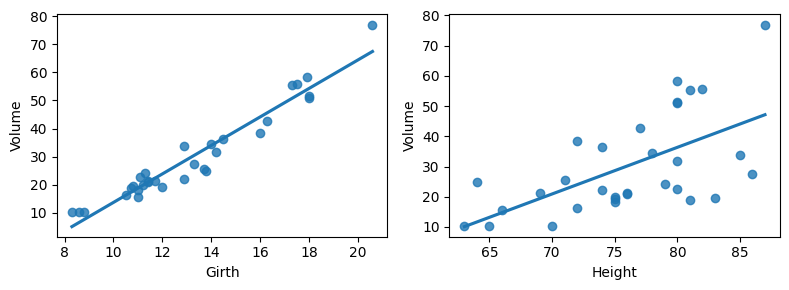

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for column, ax in zip(["Girth", "Height"], axes):
    sns.regplot(trees, x=column, y="Volume", ci=None, ax=ax)

plt.tight_layout()
plt.show()

Начнем с суммы двух признаков в формуле: это два отдельных коэффициента, а не один признак `Girth + Height`.

In [17]:
model = ols("Volume ~ Girth + Height", trees).fit()

pd.DataFrame({"coef": model.params, "p-value": model.pvalues})

,coef,p-value
Intercept,-57.987659,2.749507e-07
Girth,4.708161,8.223304e-17
Height,0.339251,1.449097e-02


Выведите скорректированный $R^2$. Постройте график остатков от предсказанных значений и проверьте предпосылки модели. Обратите внимание на форму облака остатков даже при незначимом результате теста.

In [ ]:
pd.Series({
    "Shapiro-Wilk": stats.shapiro(model.resid).pvalue,
    "Breusch-Pagan": het_breuschpagan(model.resid, model.model.exog)[3],
}, name="p-value").to_frame()

In [ ]:
pd.Series({
    "R2": model.rsquared,
    "R2 adj": model.rsquared_adj,
    "RMSE": np.sqrt(np.mean(model.resid ** 2)),
    "F p-value": model.f_pvalue,
}).to_frame("value")

Если приближать ствол цилиндром или конусом, объем пропорционален квадрату диаметра и высоте: $V \propto D^2 H$. Для начала заменим диаметр его квадратом.

В формуле `I(Girth ** 2)` означает обычную арифметическую операцию. Модель остается линейной по коэффициентам.

In [18]:
model = ols("Volume ~ I(Girth ** 2) + Height", trees).fit()

pd.DataFrame({"coef": model.params, "p-value": model.pvalues})

,coef,p-value
Intercept,-27.511603,2.483817e-04
I(Girth ** 2),0.168458,8.545141e-21
Height,0.348809,8.300124e-04


Сравните скорректированный $R^2$ и график остатков с предыдущей моделью. Повторите тесты на предпосылки.

In [ ]:
# Your code here

Теперь используем произведение $D^2 H$. Двоеточие включает только произведение; в отличие от `*`, отдельные слагаемые автоматически не добавляются. Это отдельная модель, мотивированная геометрией ствола.

In [19]:
model = ols("Volume ~ I(Girth ** 2):Height", trees).fit()

pd.DataFrame({"coef": model.params, "p-value": model.pvalues})

,coef,p-value
Intercept,-0.297679,7.595769e-01
I(Girth ** 2):Height,0.002124,1.597724e-25


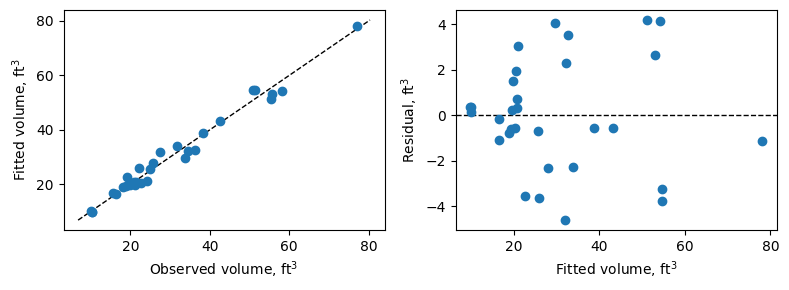

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].scatter(trees["Volume"], model.fittedvalues)
axes[0].plot(axes[0].get_xlim(), axes[0].get_xlim(), "k--", linewidth=1, zorder=0)
axes[0].set(xlabel=r"Observed volume, ft$^3$", ylabel=r"Fitted volume, ft$^3$")

axes[1].scatter(model.fittedvalues, model.resid)
axes[1].axhline(0, color="k", linestyle="--", linewidth=1, zorder=0)
axes[1].set(xlabel=r"Fitted volume, ft$^3$", ylabel=r"Residual, ft$^3$")

plt.tight_layout()
plt.show()

In [21]:
pd.Series({
    "R2 adj": model.rsquared_adj,
    "Shapiro-Wilk p-value": stats.shapiro(model.resid).pvalue,
    "Breusch-Pagan p-value": het_breuschpagan(model.resid, model.model.exog)[3],
}).to_frame("value")

,value
R2 adj,0.976999
Shapiro-Wilk p-value,0.287327
Breusch-Pagan p-value,0.019060


Несмотря на хорошее описание средней зависимости, гетероскедастичность остается. Используем устойчивую к ней оценку ковариационной матрицы **HC3**.

HC3 корректирует стандартные ошибки, p-value и интервалы. Коэффициенты, предсказания и остатки остаются прежними; сама гетероскедастичность не исчезает.

In [22]:
model_hc3 = ols("Volume ~ I(Girth ** 2):Height", trees).fit(
    cov_type="HC3", use_t=True,
)

pd.DataFrame({
    "coef": model.params,
    "SE OLS": model.bse,
    "SE HC3": model_hc3.bse,
    "p-value OLS": model.pvalues,
    "p-value HC3": model_hc3.pvalues,
}).join(model_hc3.conf_int().rename(columns={0: "CI low HC3", 1: "CI high HC3"}))

,coef,SE OLS,SE HC3,p-value OLS,p-value HC3,CI low HC3,CI high HC3
Intercept,-0.297679,0.963555,0.765789,7.595769e-01,7.003208e-01,-1.863894,1.268535
I(Girth ** 2):Height,0.002124,0.000059,0.000063,1.597724e-25,7.844753e-25,0.001996,0.002253


### Задание 4

Для **Chinstrap** постройте модель глубины клюва `bill_depth_mm`. Выберите не более трех исходных признаков; при необходимости добавьте одно обоснованное взаимодействие или преобразование.

Сравните простую и расширенную модели, обоснуйте итоговую формулу. Выведите коэффициенты с 95%-ми интервалами, скорректированный $R^2$ и RMSE. Проверьте остатки и гомоскедастичность, при необходимости используйте HC3 или преобразование переменных. Убедитесь, что результат не определяется одним необычным наблюдением. Модель должна оставаться компактной и устойчивой.

In [ ]:
# Your code here